# Cross-Dataset Comparison — Breast Cancer vs. Diabetes

The assignment requires a comparison of calibration results **across** the two datasets, not just
within each one. This notebook loads the saved metrics from `results/metrics/` (produced by
`python -m src.experiment`, which reruns both dataset experiments end to end) and compares them
side by side.

If you have changed anything in `src/`, re-run the pipeline first:
```bash
source .venv/bin/activate
python -m src.experiment
```

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

df_all = pd.read_csv(REPO_ROOT / "results" / "metrics" / "all_results.csv")
summary = pd.read_csv(REPO_ROOT / "results" / "metrics" / "summary_comparison.csv")
df_all


,dataset,model,method,accuracy,log_loss,brier_score,ece
0,breast_cancer,LogisticRegression,Uncalibrated,0.964912,0.086141,0.023921,0.022014
1,breast_cancer,LogisticRegression,Platt,0.973684,0.088540,0.022557,0.038137
2,breast_cancer,LogisticRegression,Isotonic,0.973684,0.619640,0.023018,0.024474
3,breast_cancer,RandomForest,Uncalibrated,0.982456,0.117687,0.029569,0.067193
4,breast_cancer,RandomForest,Platt,0.982456,0.094731,0.019324,0.046806
5,breast_cancer,RandomForest,Isotonic,0.973684,0.360608,0.027503,0.044083
6,diabetes,LogisticRegression,Uncalibrated,0.740260,0.517886,0.174252,0.079680
7,diabetes,LogisticRegression,Platt,0.746753,0.524148,0.174959,0.052838
8,diabetes,LogisticRegression,Isotonic,0.675325,1.568754,0.189628,0.127194
9,diabetes,RandomForest,Uncalibrated,0.720779,0.515474,0.175025,0.064589


## Test-set metrics, side by side (all dataset x model x method combinations)

In [2]:
pivot = df_all.pivot_table(
    index=["dataset", "model"], columns="method",
    values=["accuracy", "log_loss", "brier_score", "ece"],
)
pivot.round(4)


accuracy                      brier_score                           ece                      log_loss  \
method                           Isotonic   Platt Uncalibrated    Isotonic   Platt Uncalibrated Isotonic   Platt Uncalibrated Isotonic   
dataset       model                                                                                                                      
breast_cancer LogisticRegression   0.9737  0.9737       0.9649      0.0230  0.0226       0.0239   0.0245  0.0381       0.0220   0.6196   
              RandomForest         0.9737  0.9825       0.9825      0.0275  0.0193       0.0296   0.0441  0.0468       0.0672   0.3606   
diabetes      LogisticRegression   0.6753  0.7468       0.7403      0.1896  0.1750       0.1743   0.1272  0.0528       0.0797   1.5688   
              RandomForest         0.7338  0.7208       0.7208      0.1737  0.1761       0.1750   0.0464  0.0649       0.0646   0.5141   

                                                       
method                             Platt Uncalibrated  
dataset       model                                    
breast_cancer LogisticRegression  0.0885       0.0861  
              RandomForest        0.0947       0.1177  
diabetes      LogisticRegression  0.5241       0.5179  
              RandomForest        0.5226       0.5155

## Change relative to the uncalibrated baseline (mandatory cross-dataset comparison)

In [3]:
summary[["dataset", "model", "method", "delta_log_loss_vs_uncal", "delta_brier_vs_uncal", "delta_ece_vs_uncal"]]


,dataset,model,method,delta_log_loss_vs_uncal,delta_brier_vs_uncal,delta_ece_vs_uncal
0,breast_cancer,LogisticRegression,Uncalibrated,0.000000,0.000000,0.000000
1,breast_cancer,LogisticRegression,Platt,0.002400,-0.001364,0.016123
2,breast_cancer,LogisticRegression,Isotonic,0.533500,-0.000903,0.002460
3,breast_cancer,RandomForest,Uncalibrated,0.000000,0.000000,0.000000
4,breast_cancer,RandomForest,Platt,-0.022955,-0.010246,-0.020387
5,breast_cancer,RandomForest,Isotonic,0.242922,-0.002066,-0.023110
6,diabetes,LogisticRegression,Uncalibrated,0.000000,0.000000,0.000000
7,diabetes,LogisticRegression,Platt,0.006262,0.000707,-0.026842
8,diabetes,LogisticRegression,Isotonic,1.050868,0.015376,0.047514
9,diabetes,RandomForest,Uncalibrated,0.000000,0.000000,0.000000


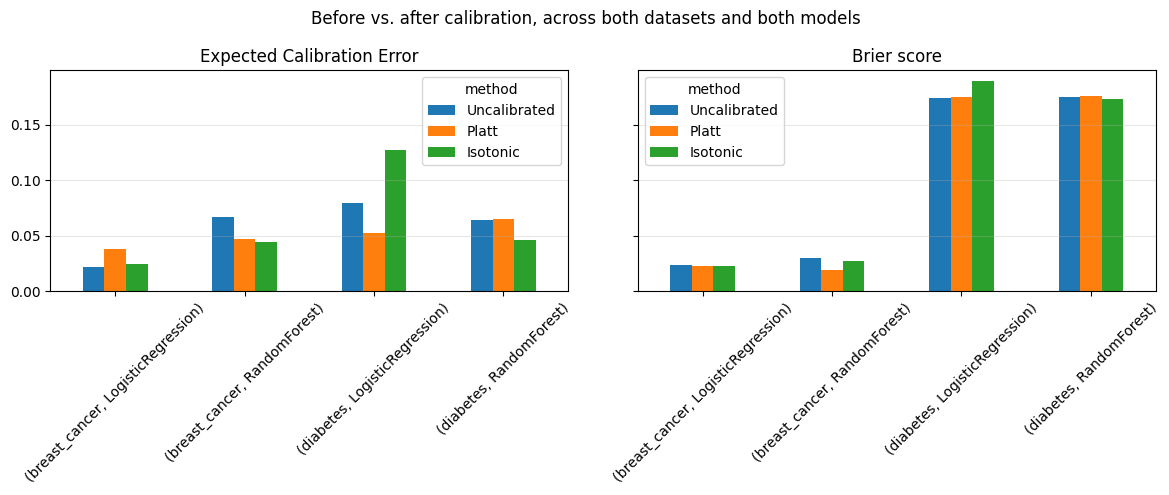

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, metric, title in zip(axes, ["ece", "brier_score"], ["Expected Calibration Error", "Brier score"]):
    piv = df_all.pivot_table(index=["dataset", "model"], columns="method", values=metric)
    piv = piv[["Uncalibrated", "Platt", "Isotonic"]]
    piv.plot.bar(ax=ax, rot=45)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Before vs. after calibration, across both datasets and both models")
fig.tight_layout()
fig.savefig(REPO_ROOT / "results" / "plots" / "cross_dataset_summary_bars.png", dpi=150, bbox_inches="tight")
plt.show()


## Discussion notes (to expand in the report)

- **Breast Cancer (well-separated, small calibration set):** both models are already close to
  well-calibrated before any correction. Isotonic regression is the more fragile method here — with a
  perfectly rank-separated calibration set it degenerates into hard 0/1 predictions, which is harmless
  for Brier score/accuracy but can badly hurt log-loss on any test point it gets wrong. Platt scaling's
  built-in label smoothing avoids this failure mode entirely.
- **Diabetes (noisier, less separable):** predicted probabilities spread more evenly across [0, 1], so
  isotonic regression has enough points per pooled block to behave more like genuine non-parametric
  smoothing rather than memorization. This is where isotonic regression's extra flexibility (versus
  Platt's 2-parameter sigmoid) has more room to pay off.
- **Random Forest vs. Logistic Regression:** Logistic Regression directly optimizes log-likelihood
  during training, so it tends to start closer to well-calibrated. Random Forest's probability
  averaging across many trees tends to compress predictions toward the middle of [0, 1] (values rarely
  reach very close to 0 or 1), which is a form of under-confidence at the extremes — check the
  reliability plots in the per-dataset notebooks to confirm this pattern on each dataset.
- Fill in the *specific* numbers from the tables above (which method reduced log-loss / Brier / ECE the
  most, by how much, for which model+dataset) before writing this up in `report/`.